In [28]:
import timesfm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm 
import os 
from itertools import product
from collections import defaultdict
import time

from timesfm_functions import (
    TimesFMModel,
    load_aluminium_data,
    calculate_prediction_metrics
)

from functions import line_plot, mape, mae, rmse, mse, mase, pred_value_to_char

In [29]:
def calculate_prediction_metrics(predictions, true_values):
    """
    Calculate common error metrics to evaluate prediction accuracy.

    Parameters
    ----------
    predictions : array-like
        The predicted values from a model.
    true_values : array-like
        The actual observed/true values.

    Returns
    -------
    dict
        A dictionary containing:
        - "MAPE": Mean Absolute Percentage Error
            Measures prediction accuracy as a percentage; lower is better.
        - "MAE": Mean Absolute Error
            Average of absolute differences between predictions and true values.
        - "RMSE": Root Mean Squared Error
            Square root of average squared differences; penalizes large errors.
        - "MSE": Mean Squared Error
            Average of squared differences; sensitive to outliers.
        - "MASE": Mean Absolute Scaled Error
            Scale-independent error metric useful for comparing across datasets.
    """

    # Coerce to numpy arrays
    y_pred = np.asarray(predictions)
    y_true = np.asarray(true_values)

    # Make them column vectors if 1D
    if y_pred.ndim == 1:
        y_pred = y_pred.reshape(-1, 1)
    if y_true.ndim == 1:
        y_true = y_true.reshape(-1, 1)

    # Align lengths (guard against off-by-one slicing)
    n = min(len(y_pred), len(y_true))
    if n == 0:
        raise ValueError("Empty inputs: predictions/true_values have no overlapping length.")
    y_pred = y_pred[:n]
    y_true = y_true[:n]


    mape_val = mape(true_values, predictions)
    mae_val = mae(true_values, predictions)
    rmse_val = rmse(true_values, predictions)
    mse_val = mse(true_values, predictions)
    mase_val = mase(true_values, predictions) 

    return {
        "MAPE": mape_val,
        "MAE": mae_val,
        "RMSE": rmse_val,
        "MSE": mse_val,
        "MASE": mase_val
    }

In [30]:
df = pd.read_csv('https://datasets-nixtla.s3.amazonaws.com/EPF_FR_BE.csv')
df['ds'] = pd.to_datetime(df['ds'])

In [31]:
batch_size = 64
context_len = 128
horizon_len = 32

In [32]:
# Data pipelining
def get_batched_data_fn(batch_size, context_len, horizon_len):
  examples = defaultdict(list)

  num_examples = 0
  for country in ("FR", "BE"):
    sub_df = df[df["unique_id"] == country]
    for start in range(0, len(sub_df) - (context_len + horizon_len), horizon_len):
      num_examples += 1
      examples["country"].append(country)
      examples["inputs"].append(sub_df["y"][start:(context_end := start + context_len)].tolist())
      examples["gen_forecast"].append(sub_df["gen_forecast"][start:context_end + horizon_len].tolist())
      examples["week_day"].append(sub_df["week_day"][start:context_end + horizon_len].tolist())
      examples["outputs"].append(sub_df["y"][context_end:(context_end + horizon_len)].tolist())
  
  def data_fn():
    for i in range(1 + (num_examples - 1) // batch_size):
      yield {k: v[(i * batch_size) : ((i + 1) * batch_size)] for k, v in examples.items()}
  
  return data_fn

In [33]:
def mse(y_pred, y_true):
    y_pred = np.asarray(y_pred)
    y_true = np.asarray(y_true)
    return np.mean((y_pred - y_true) ** 2, axis=-1)  # scalar for 1D, length-N for 2D

def mae(y_pred, y_true):
    y_pred = np.asarray(y_pred)
    y_true = np.asarray(y_true)
    return np.mean(np.abs(y_pred - y_true), axis=-1)

In [ ]:
timesfm_backend = "gpu"

model = TimesFMModel(expiry=horizon_len, context_length=context_len, positional_embedding=False)

Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 16435.36it/s]


In [43]:
all_data = []
all_inputs = []
for i, example in enumerate(input_data()):
    all_inputs.append(example['inputs'])
    print(example['inputs'])
    raw_forecast, _ = model.predict(
        forecast_input=example["inputs"], frequency_input=[0] * len(example["inputs"])
    )
    all_data.append(raw_forecast)
    print(raw_forecast, len(raw_forecast[0]))
    if i == 1: break

[[53.48, 51.93, 48.76, 42.27, 38.41, 35.72, 32.66, 32.83, 30.06, 29.24, 37.54, 41.19, 44.69, 39.77, 33.29, 32.47, 34.73, 40.95, 51.25, 52.55, 49.55, 46.31, 48.75, 47.59, 38.8, 36.73, 33.52, 27.5, 22.84, 26.1, 27.17, 33.33, 42.06, 46.13, 44.05, 45.3, 48.64, 44.87, 41.0, 39.78, 39.73, 50.24, 54.1, 53.13, 48.81, 42.99, 48.76, 48.45, 46.97, 43.27, 41.76, 37.54, 32.99, 31.24, 36.71, 39.47, 44.51, 44.45, 45.01, 45.36, 45.6, 43.4, 39.6, 35.48, 33.85, 45.96, 49.82, 47.62, 43.79, 42.44, 42.03, 40.91, 36.26, 32.28, 27.63, 23.94, 15.69, 18.14, 20.03, 19.23, 27.31, 34.54, 36.7, 37.14, 42.55, 38.34, 32.68, 25.25, 30.43, 43.04, 54.35, 51.57, 49.99, 41.18, 44.79, 42.96, 36.56, 34.94, 32.19, 23.53, 22.92, 34.26, 44.28, 50.38, 53.79, 52.03, 50.6, 50.5, 48.45, 44.54, 42.0, 43.1, 46.7, 56.78, 58.84, 53.6, 46.9, 44.58, 48.7, 46.06, 45.56, 40.28, 39.2, 36.22, 34.04, 38.58, 43.32, 50.0], [42.06, 46.13, 44.05, 45.3, 48.64, 44.87, 41.0, 39.78, 39.73, 50.24, 54.1, 53.13, 48.81, 42.99, 48.76, 48.45, 46.97, 43.2

In [76]:
arr = np.array(df['y'].tolist())
np.where(arr == 33.85)

(array([   64, 12117, 12607, 21136, 27308, 28197, 30494, 30846]),)

In [35]:
input_data = get_batched_data_fn(batch_size = batch_size, context_len=context_len, horizon_len=horizon_len)
metrics = defaultdict(list)


for i, example in enumerate(input_data()):
    raw_forecast, _ = model.predict(
        forecast_input=example["inputs"], frequency_input=[0] * len(example["inputs"])
    )
    start_time = time.time()
    # Forecast with covariates
    # Output: new forecast, forecast by the xreg
    cov_forecast, ols_forecast = model.predict_with_covariates(
        inputs=example["inputs"],
        dynamic_numerical_covariates={
            "gen_forecast": example["gen_forecast"],
        },
        dynamic_categorical_covariates={
            "week_day": example["week_day"],
        },
        static_numerical_covariates={},
        static_categorical_covariates={
            "country": example["country"]
        },
        freq=[0] * len(example["inputs"]),
        xreg_mode="xreg + timesfm",
        ridge=0.0,
        force_on_cpu=False,
        normalize_xreg_target_per_input=True,
    )
    print(
        f"\rFinished batch {i} linear in {time.time() - start_time} seconds",
        end="",
    )
    metrics["eval_mae_timesfm"].extend(
        mae(raw_forecast[:, :horizon_len], example["outputs"])
    )
    metrics["eval_mae_xreg_timesfm"].extend(mae(cov_forecast, example["outputs"]))
    metrics["eval_mae_xreg"].extend(mae(ols_forecast, example["outputs"]))
    metrics["eval_mse_timesfm"].extend(
        mse(raw_forecast[:, :horizon_len], example["outputs"])
    )
    metrics["eval_mse_xreg_timesfm"].extend(mse(cov_forecast, example["outputs"]))
    metrics["eval_mse_xreg"].extend(mse(ols_forecast, example["outputs"]))

print()

for k, v in metrics.items():
  print(f"{k}: {np.mean(v)}")

# My output:
# eval_mae_timesfm: 6.762283045916956
# eval_mae_xreg_timesfm: 5.39219617611074
# eval_mae_xreg: 37.15275842572484
# eval_mse_timesfm: 166.7771466306823
# eval_mse_xreg_timesfm: 120.64757721021306
# eval_mse_xreg: 1672.2116821201796

Finished batch 15 linear in 0.3833045959472656 secondss
eval_mae_timesfm: 6.239665260259885
eval_mae_xreg_timesfm: 5.127462220979438
eval_mae_xreg: 37.152904317345055
eval_mse_timesfm: 133.79493352535232
eval_mse_xreg_timesfm: 117.49114320886063
eval_mse_xreg: 1669.8854122499545


In [36]:
cov_forecast = np.array(cov_forecast)
print(raw_forecast.shape, cov_forecast.shape)

(36, 32) (36, 32)


190.5185203656526
209.2629165519624


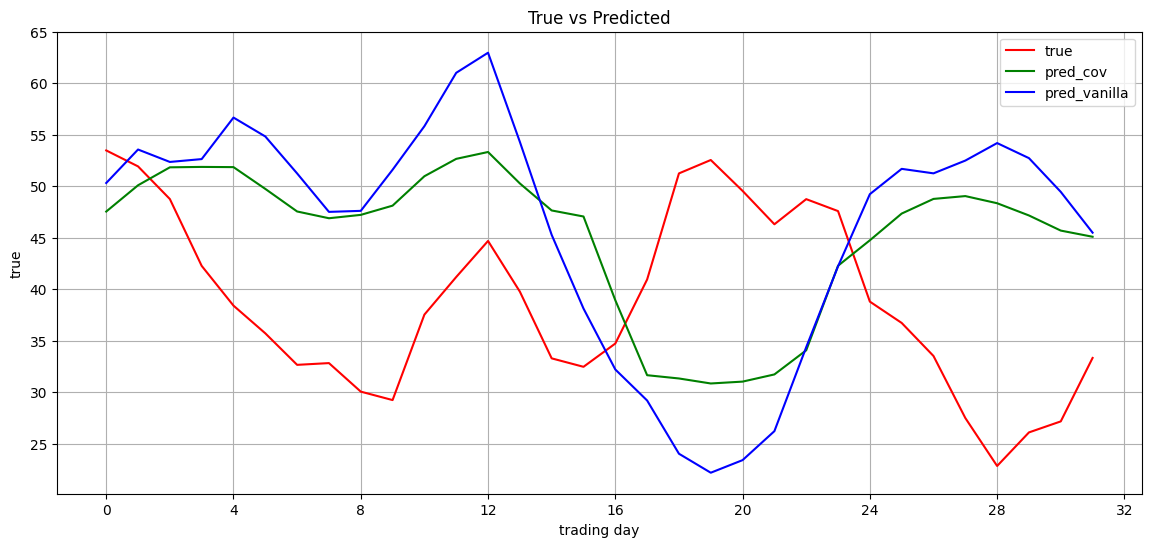

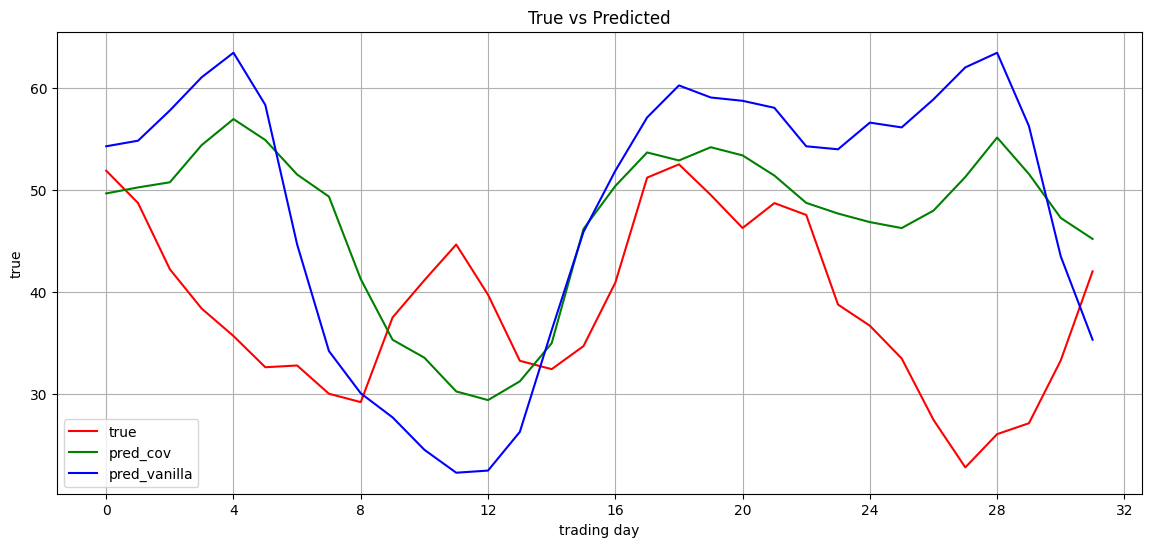

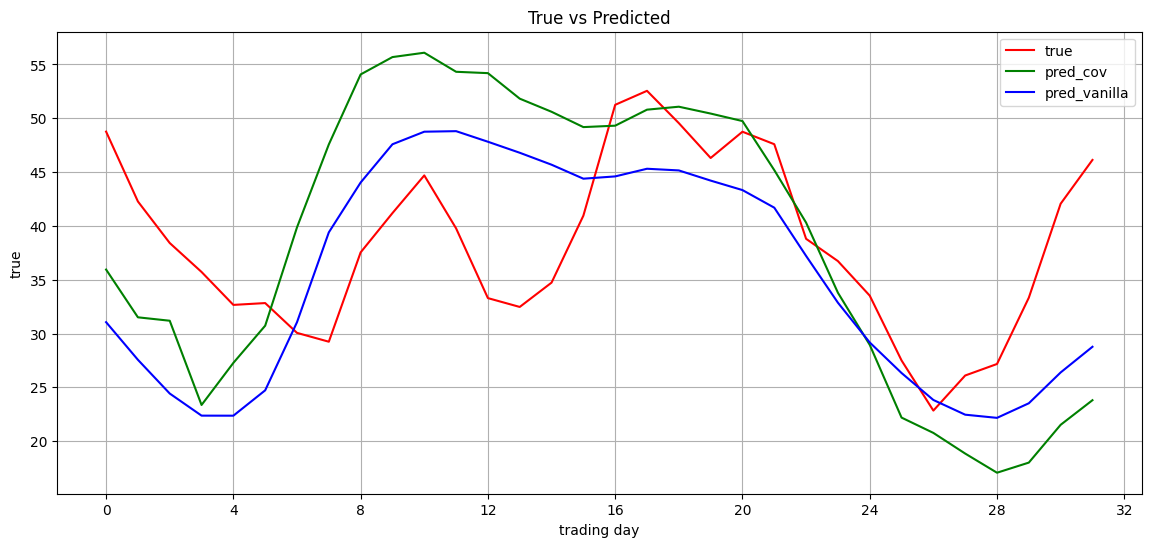

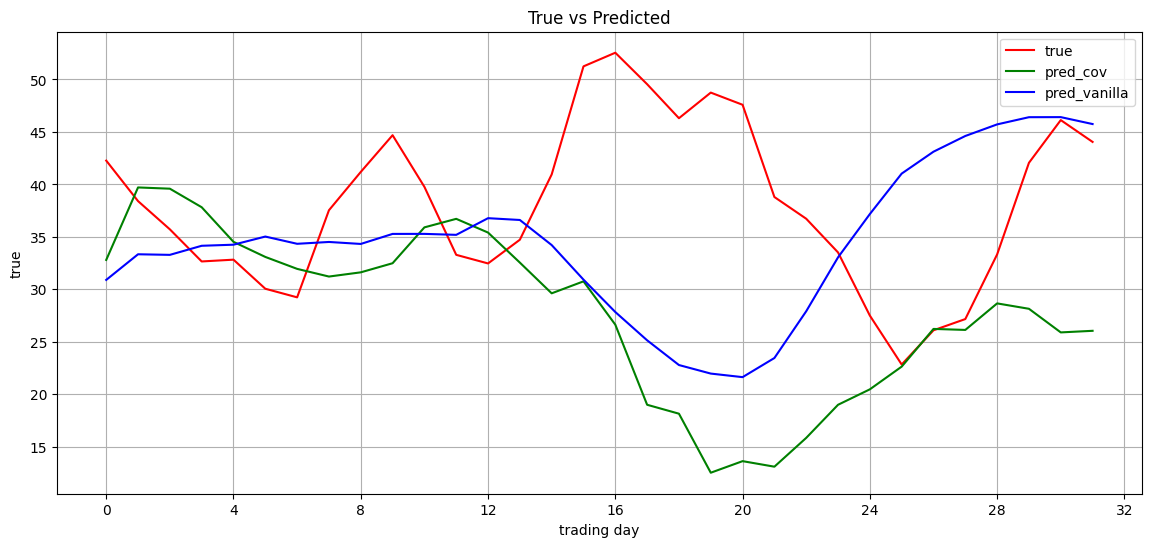

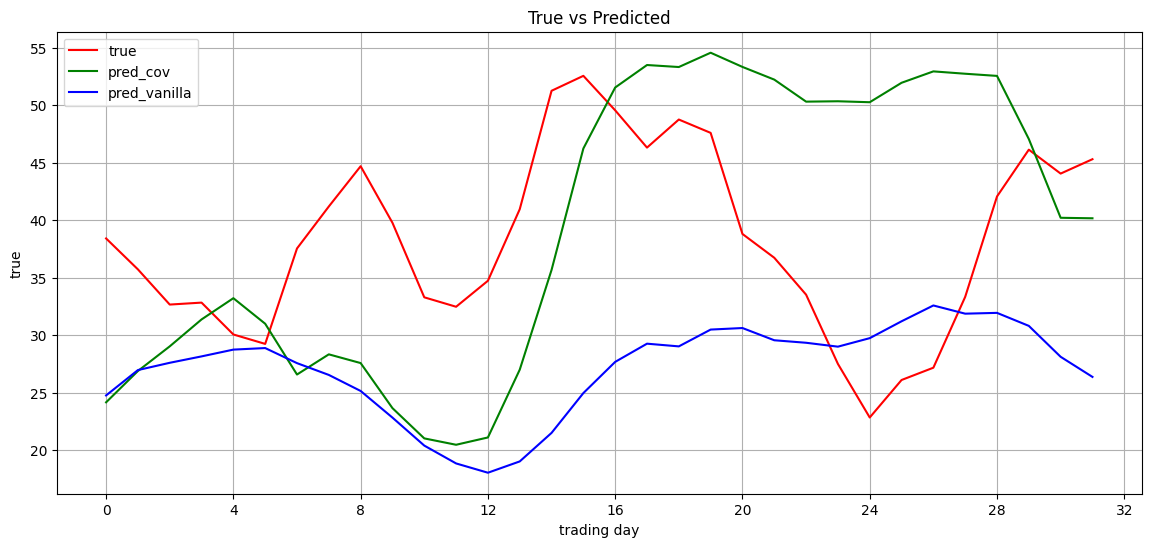

In [37]:
for i in range(5):
    pred = raw_forecast[i, :]
    pred_cov = cov_forecast[i, :]
    true = list(df['y'][i:len(pred)+i])

    ax, fig = line_plot(true, true, 'true', graphtitle='True vs Predicted', linecolor='red', show=False)
    ax, fig = line_plot(pred_cov, pred_cov, 'pred_cov', linecolor='green', ax=ax, show=False)
    _, _ = line_plot(pred, pred, 'pred_vanilla', ax=ax, show=True)

print(mse(true, pred_cov))
print(mse(true, pred))

In [38]:
import timesfm
timesfm_backend = "gpu"  # @param

model = timesfm.TimesFm(
      hparams=timesfm.TimesFmHparams(
          backend=timesfm_backend,
          per_core_batch_size=32,
          horizon_len=horizon_len,
          num_layers=50,
          use_positional_embedding=False,
          context_len=context_len,
      ),
      checkpoint=timesfm.TimesFmCheckpoint(
          huggingface_repo_id="google/timesfm-2.0-500m-pytorch"),
  )

Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 25236.49it/s]


KeyboardInterrupt: 

In [ ]:
input_data = get_batched_data_fn(batch_size = batch_size, context_len=context_len, horizon_len=horizon_len)
metrics = defaultdict(list)


for i, example in enumerate(input_data()):
    raw_forecast, _ = model.forecast(
        inputs=example["inputs"], freq=[0] * len(example["inputs"])
    )
    start_time = time.time()
    # Forecast with covariates
    # Output: new forecast, forecast by the xreg
    cov_forecast, ols_forecast = model.forecast_with_covariates(  
        inputs=example["inputs"],
        dynamic_numerical_covariates={
            "gen_forecast": example["gen_forecast"],
        },
        dynamic_categorical_covariates={
            "week_day": example["week_day"],
        },
        static_numerical_covariates={},
        static_categorical_covariates={
            "country": example["country"]
        },
        freq=[0] * len(example["inputs"]),
        xreg_mode="xreg + timesfm",              # default
        ridge=0.0,
        force_on_cpu=False,
        normalize_xreg_target_per_input=True,    # default
    )
    break
    print(
        f"\rFinished batch {i} linear in {time.time() - start_time} seconds",
        end="",
    )
    metrics["eval_mae_timesfm"].extend(
        mae(raw_forecast[:, :horizon_len], example["outputs"])
    )
    metrics["eval_mae_xreg_timesfm"].extend(mae(cov_forecast, example["outputs"]))
    metrics["eval_mae_xreg"].extend(mae(ols_forecast, example["outputs"]))
    metrics["eval_mse_timesfm"].extend(
        mse(raw_forecast[:, :horizon_len], example["outputs"])
    )
    metrics["eval_mse_xreg_timesfm"].extend(mse(cov_forecast, example["outputs"]))
    metrics["eval_mse_xreg"].extend(mse(ols_forecast, example["outputs"]))

print()

for k, v in metrics.items():
  print(f"{k}: {np.mean(v)}")

# My output:
# eval_mae_timesfm: 6.762283045916956
# eval_mae_xreg_timesfm: 5.39219617611074
# eval_mae_xreg: 37.15275842572484
# eval_mse_timesfm: 166.7771466306823
# eval_mse_xreg_timesfm: 120.64757721021306
# eval_mse_xreg: 1672.2116821201796

In [ ]:
cov_forecast = np.array(cov_forecast)
print(raw_forecast.shape, cov_forecast.shape)

(64, 32) (64, 32)


101.4604523034265
188.8513086477272


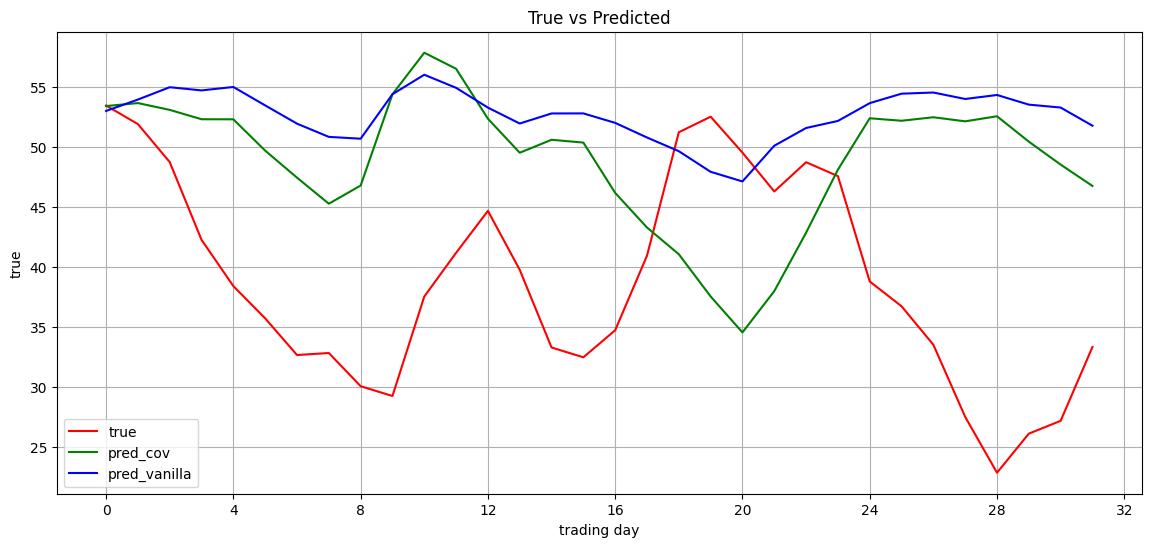

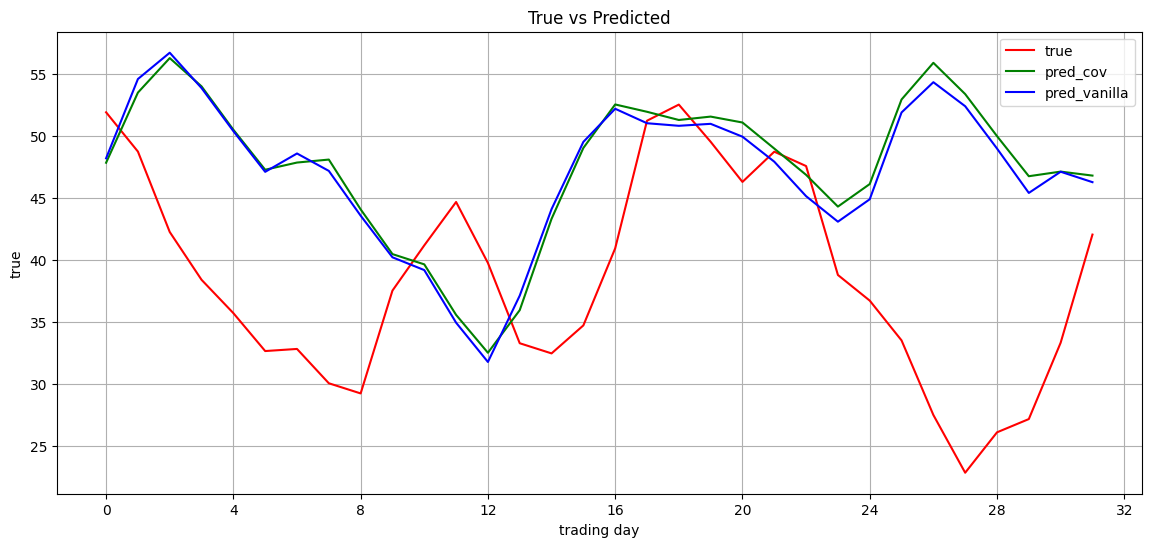

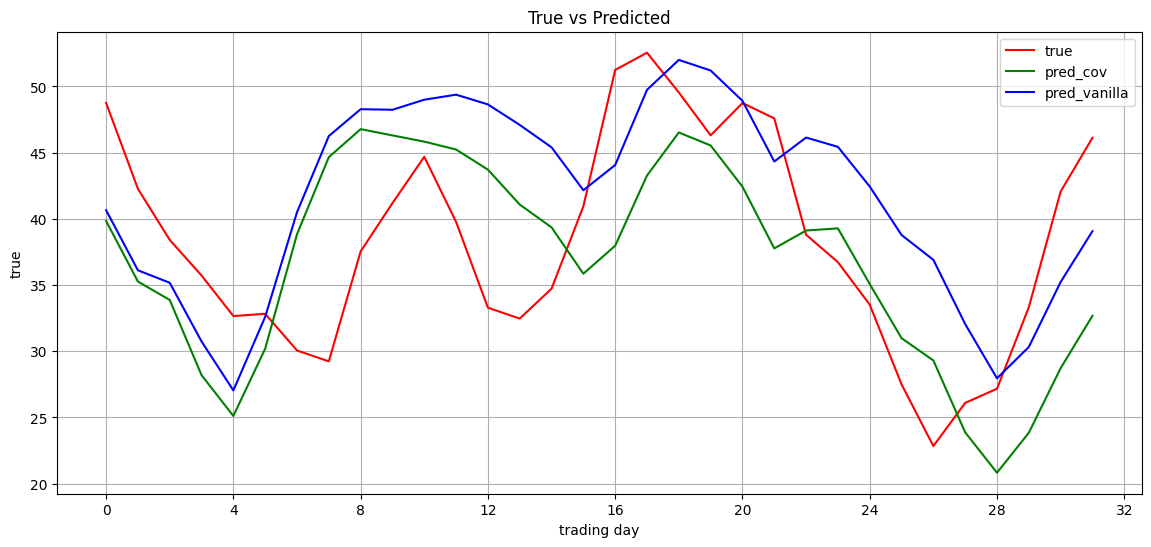

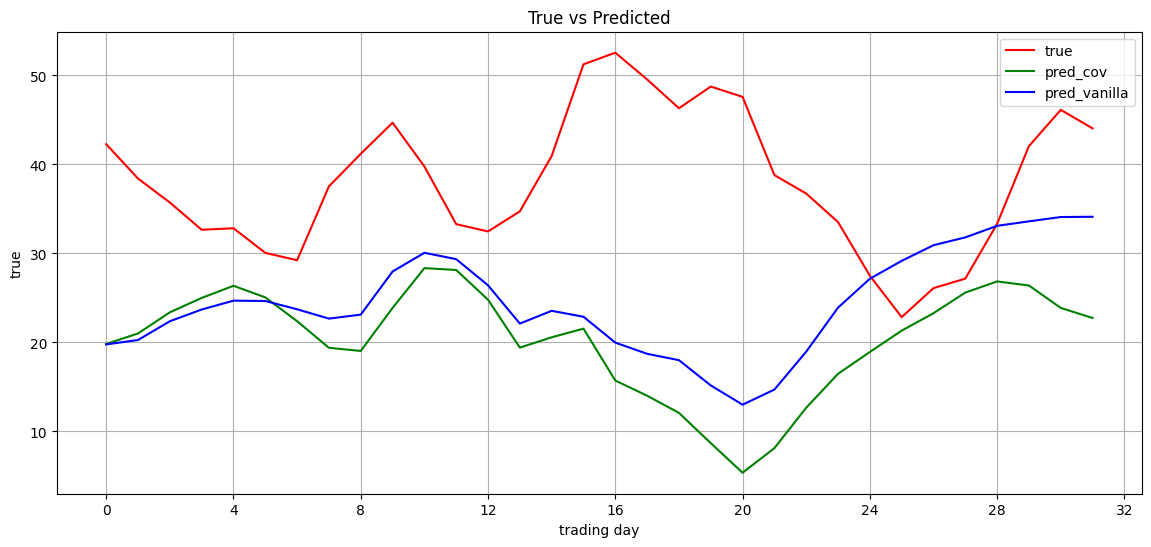

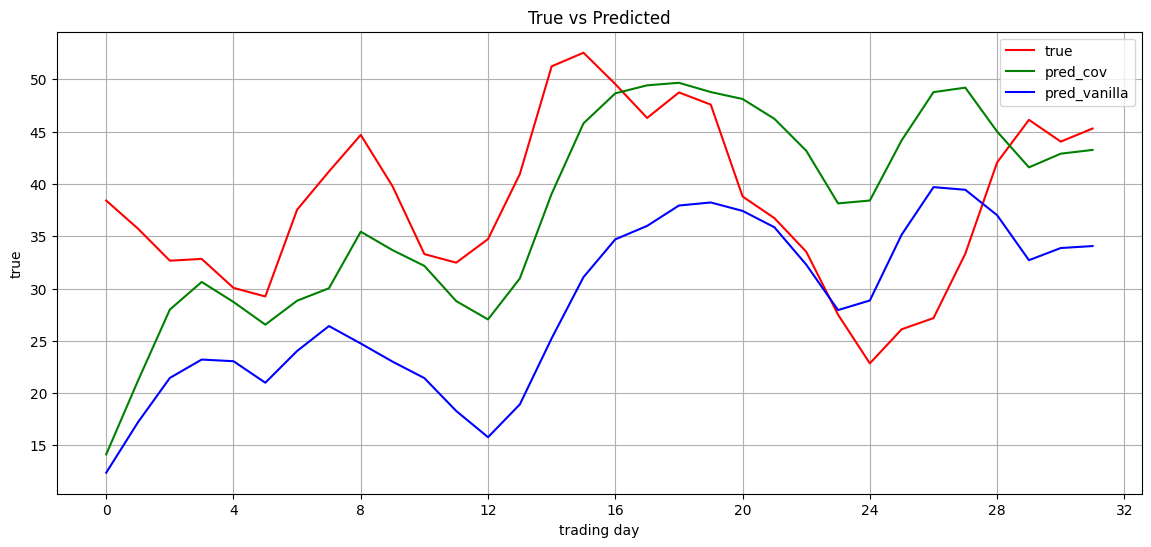

In [ ]:
for i in range(5):
    pred = raw_forecast[i, :]
    pred_cov = cov_forecast[i, :]
    true = list(df['y'][i:len(pred)+i])

    ax, fig = line_plot(true, true, 'true', graphtitle='True vs Predicted', linecolor='red', show=False)
    ax, fig = line_plot(pred_cov, pred_cov, 'pred_cov', linecolor='green', ax=ax, show=False)
    _, _ = line_plot(pred, pred, 'pred_vanilla', ax=ax, show=True)

print(mse(true, pred_cov))
print(mse(true, pred))

In [ ]:
path = ('../../Feature_selection/absolute_feature_correlations.csv')

In [ ]:
corr = pd.read_csv('../../Feature_selection/absolute_feature_correlations.csv', index_col=0)

In [ ]:
corr

,1w_exp,1m_exp,3m_exp,1y_exp
al_lme_closing_stock,0.223139,0.329128,0.484671,0.729811
us_treasuries_2y,0.118231,0.204945,0.327778,0.640562
indian_rupee_spot,0.175006,0.259668,0.378639,0.613622
japanese_yen_spot,0.150793,0.228774,0.344338,0.595440
us_dollar_index,0.107255,0.169645,0.284943,0.590856
us_treasuries_10y,0.118603,0.202728,0.330833,0.586209
ftse_bric_50_index,0.141859,0.216270,0.312653,0.583466
south_korean_won_spot,0.131547,0.179789,0.295251,0.561627
euro_spot,0.103036,0.162963,0.266805,0.545937
spx_small_cap_index,0.310530,0.437874,0.538759,0.515493
